<a href="https://colab.research.google.com/github/RamEllaboina/android_chat_app/blob/main/Iris_Species_Classification_using_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================
# IRIS SPECIES CLASSIFICATION
# Complete Machine Learning Pipeline
# ============================================
# Author: [Your Name]
# Date: June 2026
# Dataset: Iris Classification Dataset
# Goal: Predict iris species using sepal/petal measurements
# ============================================

print("="*70)
print("IRIS SPECIES CLASSIFICATION - ML PIPELINE")
print("="*70)
print("\nThis notebook implements a complete ML pipeline for Iris classification")
print("including EDA, model training, hyperparameter tuning, and deployment.")
print("\n" + "="*70)

IRIS SPECIES CLASSIFICATION - ML PIPELINE

This notebook implements a complete ML pipeline for Iris classification
including EDA, model training, hyperparameter tuning, and deployment.



In [6]:
# ============================================
# 1. INSTALL AND IMPORT LIBRARIES
# ============================================

# Install any missing packages (if running in Colab)
!pip install -q numpy pandas scikit-learn matplotlib seaborn joblib

# Import libraries
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import scikit-learn components
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, precision_score,
                             recall_score, f1_score)

import joblib
import pickle
import warnings
import os
from datetime import datetime

# Suppress warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Print versions
print("="*70)
print("LIBRARY VERSIONS")
print("="*70)
print(f"Python: {sys.version.split()[0]}")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Matplotlib: {plt.matplotlib.__version__}")
print(f"Seaborn: {sns.__version__}")
print(f"Joblib: {joblib.__version__}")
print("="*70)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create directories for outputs
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("\n✓ All libraries imported successfully!")
print("✓ Directories created: 'plots' and 'models'")

LIBRARY VERSIONS
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.2.2
Scikit-learn: 1.6.1
Matplotlib: 3.10.0
Seaborn: 0.13.2
Joblib: 1.5.3

✓ All libraries imported successfully!
✓ Directories created: 'plots' and 'models'


In [7]:
# ============================================
# 2. LOAD AND EXPLORE DATA
# ============================================

# Load Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Create DataFrame
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y
df['species_name'] = df['species'].map({i: name for i, name in enumerate(target_names)})

# Display dataset information
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"Dataset shape: {df.shape}")
print(f"\nFeatures: {feature_names}")
print(f"Target classes: {target_names}")
print(f"\nClass distribution:")
print(df['species_name'].value_counts())

print("\nFirst 5 rows:")
display(df.head())

print("\nStatistical Summary:")
display(df[feature_names].describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

DATASET OVERVIEW
Dataset shape: (150, 6)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']

Class distribution:
species_name
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa



Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
species_name         0
dtype: int64



3.1 PAIRPLOT - PAIRWISE RELATIONSHIPS


<Figure size 1400x1000 with 0 Axes>

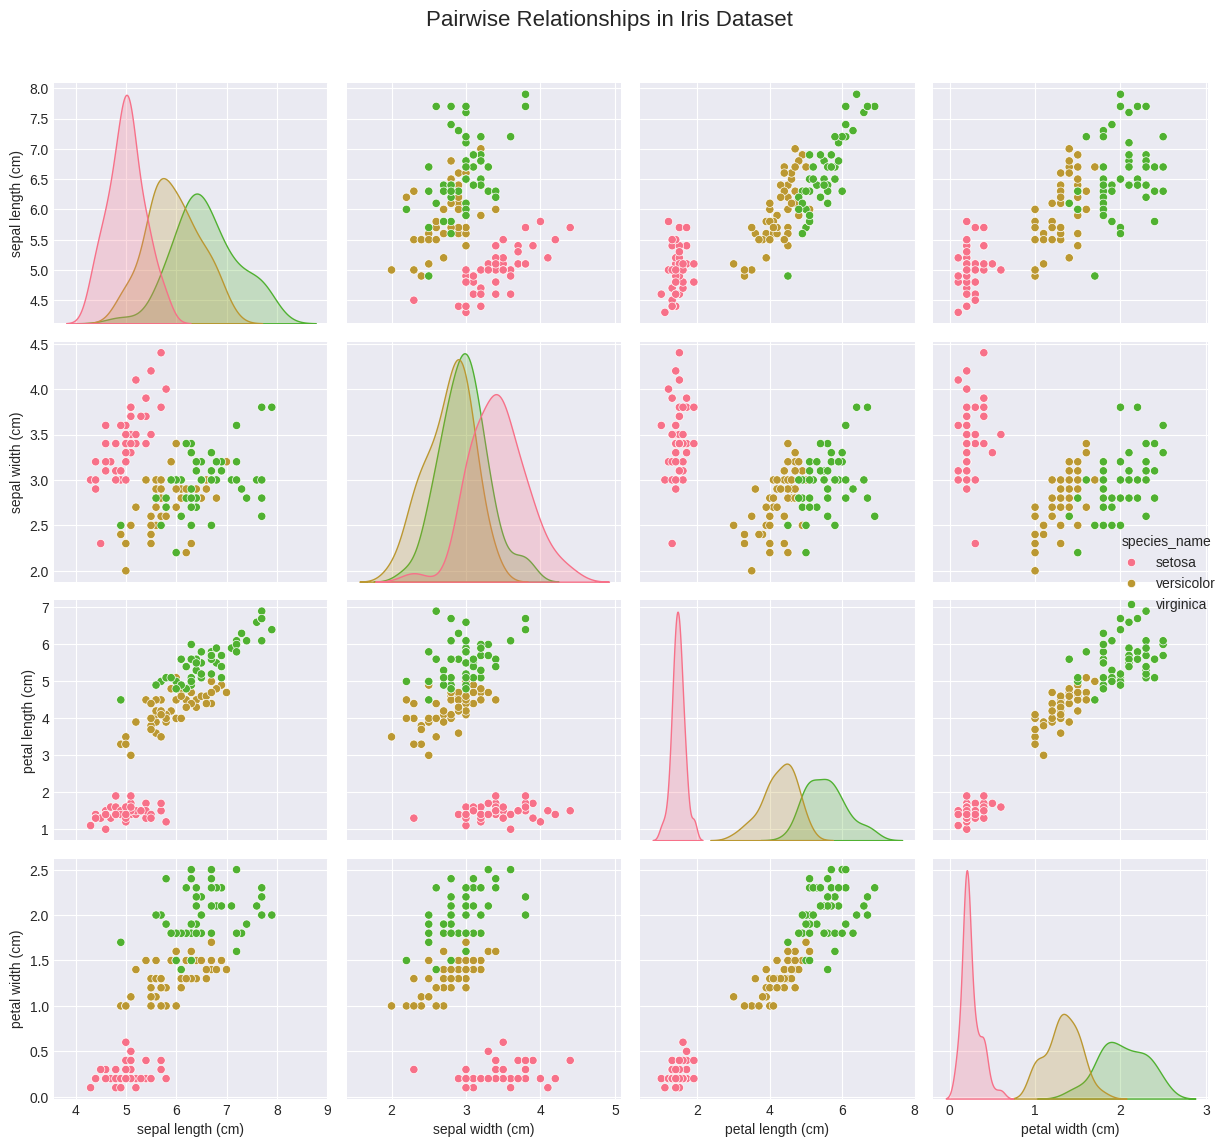

✓ Pairplot saved as 'plots/pairplot.png'


In [8]:
# ============================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ============================================

# 3.1 Pairplot - Pairwise Relationships
print("\n" + "="*70)
print("3.1 PAIRPLOT - PAIRWISE RELATIONSHIPS")
print("="*70)

fig = plt.figure(figsize=(14, 10))
pairplot = sns.pairplot(df, hue='species_name', vars=feature_names,
                        diag_kind='kde', height=2.8)
pairplot.fig.suptitle('Pairwise Relationships in Iris Dataset', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('plots/pairplot.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Pairplot saved as 'plots/pairplot.png'")


3.2 FEATURE DISTRIBUTIONS BY SPECIES


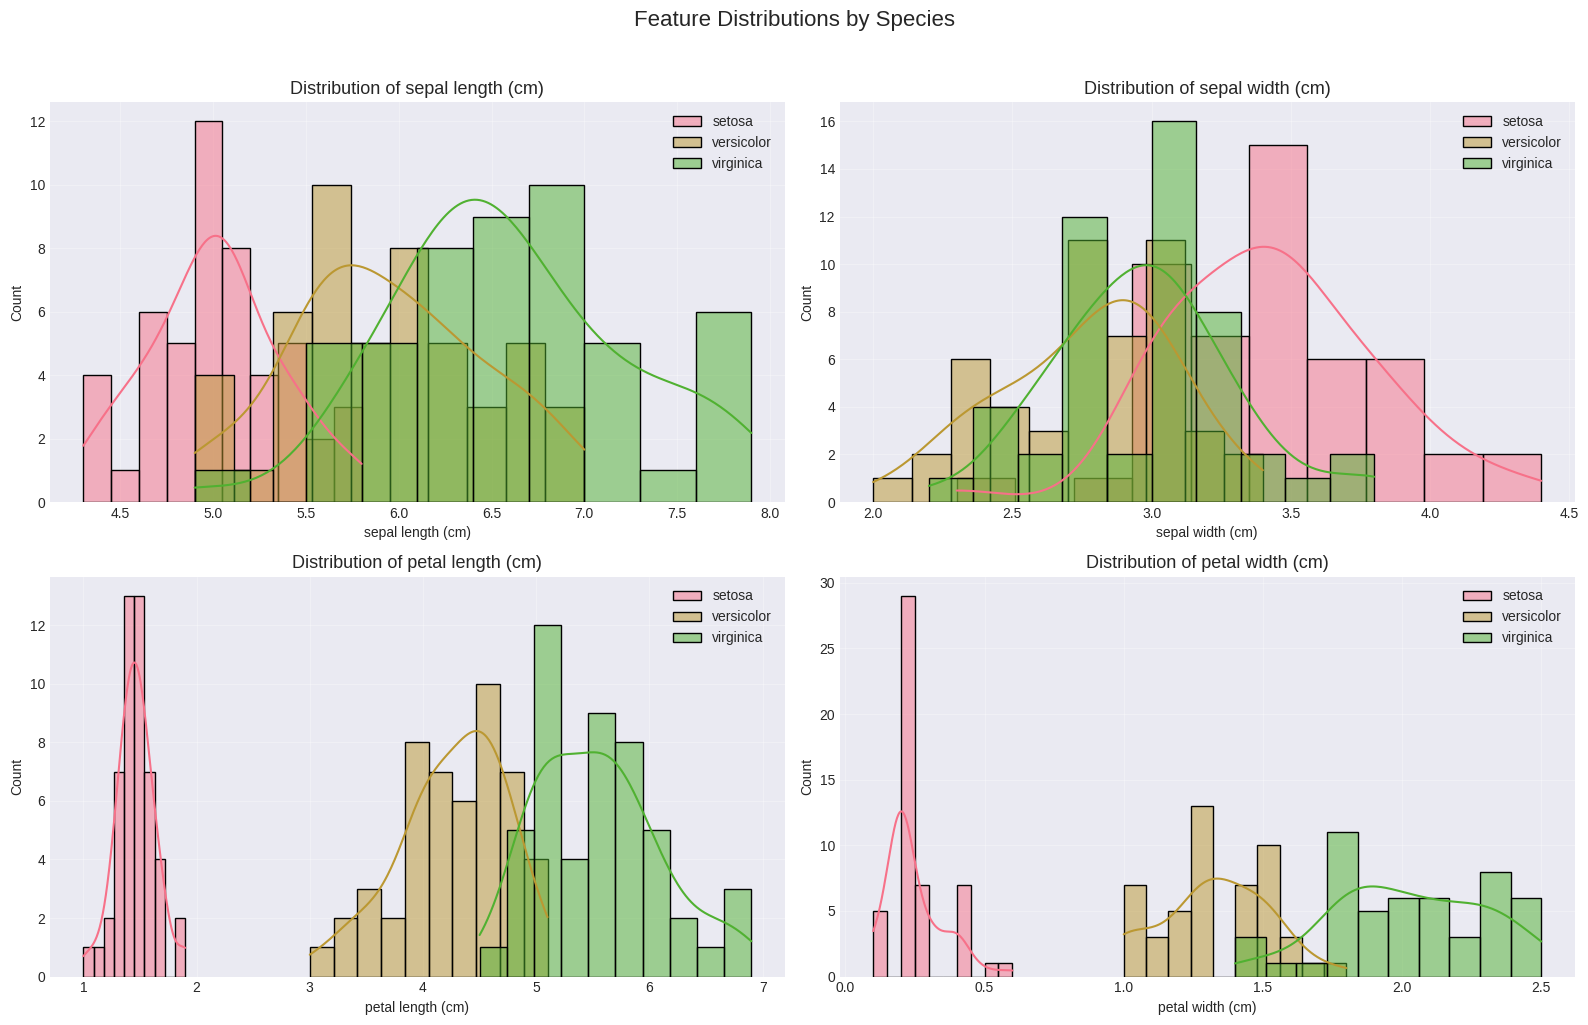

✓ Distribution plots saved as 'plots/distributions.png'


In [9]:
# 3.2 Distribution Plots - Feature Distributions by Species
print("\n" + "="*70)
print("3.2 FEATURE DISTRIBUTIONS BY SPECIES")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    for species in target_names:
        subset = df[df['species_name'] == species]
        sns.histplot(subset[feature], label=species, kde=True,
                    alpha=0.5, ax=axes[idx], bins=10)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=13)
    axes[idx].set_xlabel(feature)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distributions by Species', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/distributions.png', dpi=300)
plt.show()
print("✓ Distribution plots saved as 'plots/distributions.png'")


3.3 CLASS SEPARABILITY - BOX PLOTS


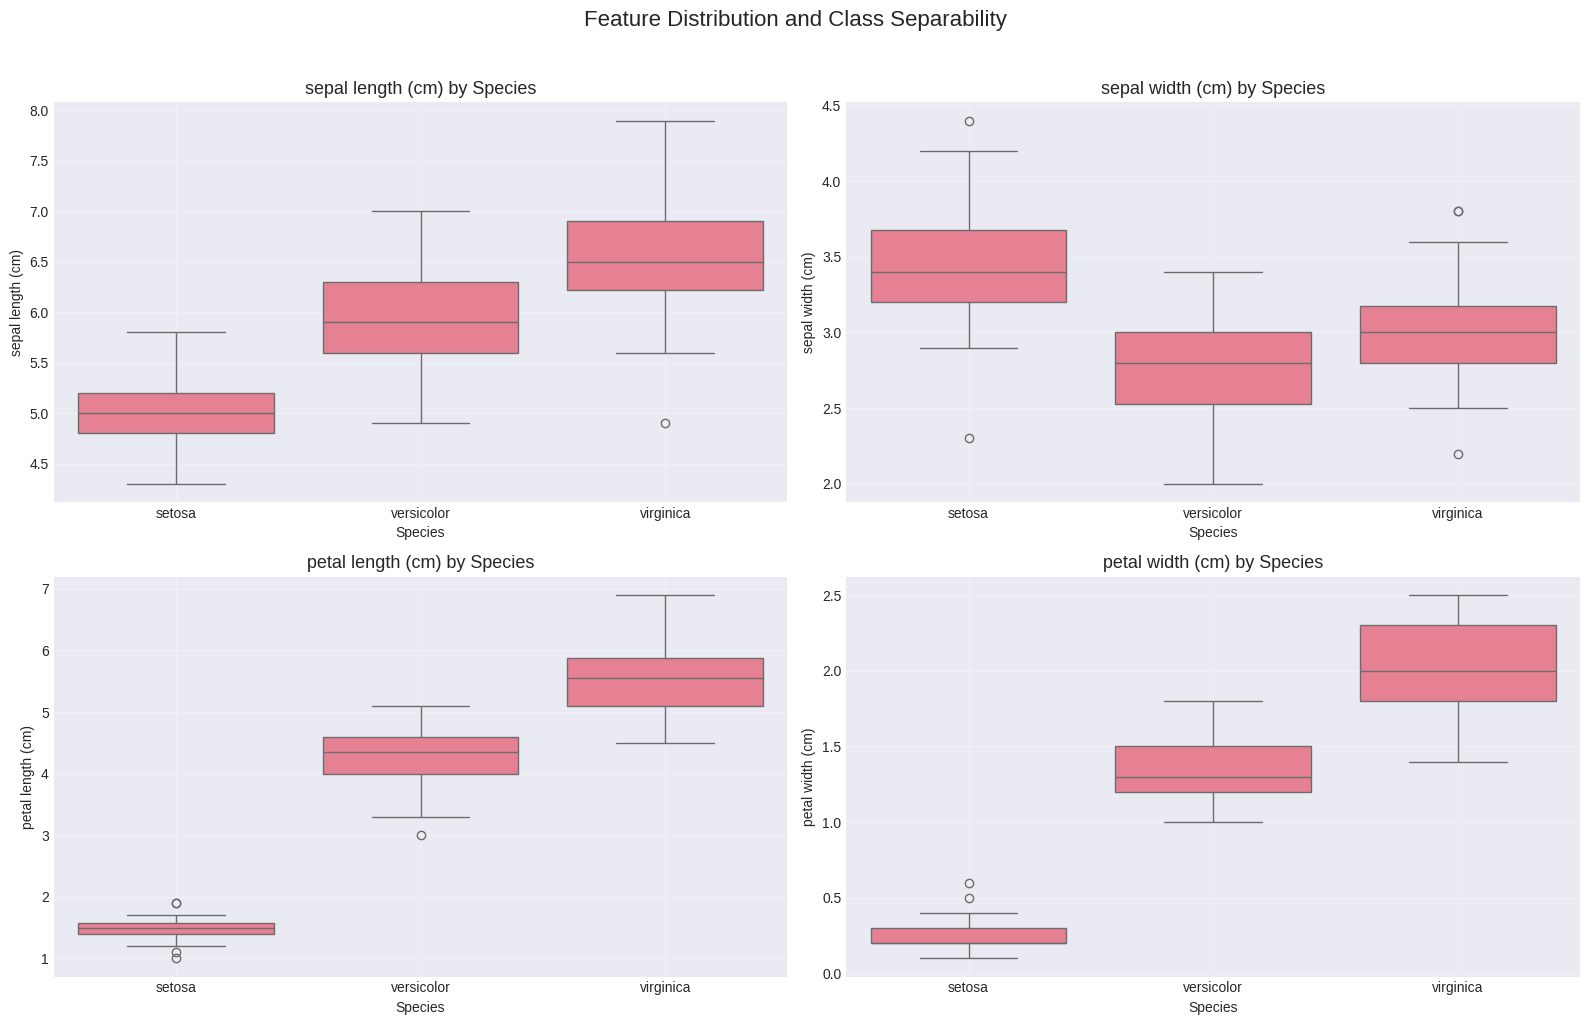

✓ Box plots saved as 'plots/boxplots.png'


In [10]:
# 3.3 Box Plots - Class Separability
print("\n" + "="*70)
print("3.3 CLASS SEPARABILITY - BOX PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(feature_names):
    sns.boxplot(data=df, x='species_name', y=feature, ax=axes[idx])
    axes[idx].set_title(f'{feature} by Species', fontsize=13)
    axes[idx].set_xlabel('Species')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Feature Distribution and Class Separability', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/boxplots.png', dpi=300)
plt.show()
print("✓ Box plots saved as 'plots/boxplots.png'")


3.4 FEATURE CORRELATION


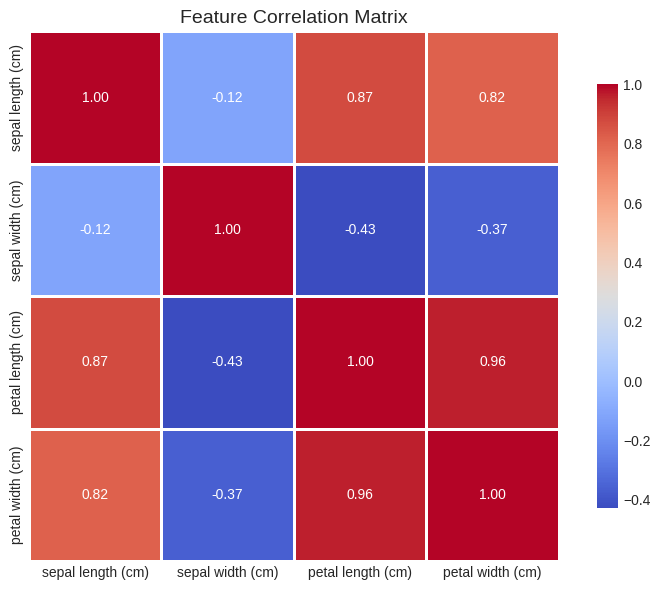

✓ Correlation matrix saved as 'plots/correlation_matrix.png'

Feature Correlations with Target (using numeric species):
  petal width (cm): 0.9565
  petal length (cm): 0.9490
  sepal length (cm): 0.7826
  sepal width (cm): -0.4267


In [11]:
# 3.4 Correlation Matrix
print("\n" + "="*70)
print("3.4 FEATURE CORRELATION")
print("="*70)

fig, ax = plt.subplots(figsize=(8, 6))
correlation_matrix = df[feature_names].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=1, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('plots/correlation_matrix.png', dpi=300)
plt.show()
print("✓ Correlation matrix saved as 'plots/correlation_matrix.png'")

print("\nFeature Correlations with Target (using numeric species):")
correlations = []
for feature in feature_names:
    corr = np.corrcoef(df[feature], df['species'])[0, 1]
    correlations.append((feature, corr))
for feature, corr in sorted(correlations, key=lambda x: abs(x[1]), reverse=True):
    print(f"  {feature}: {corr:.4f}")


3.5 CLASS SEPARABILITY - SCATTER PLOTS


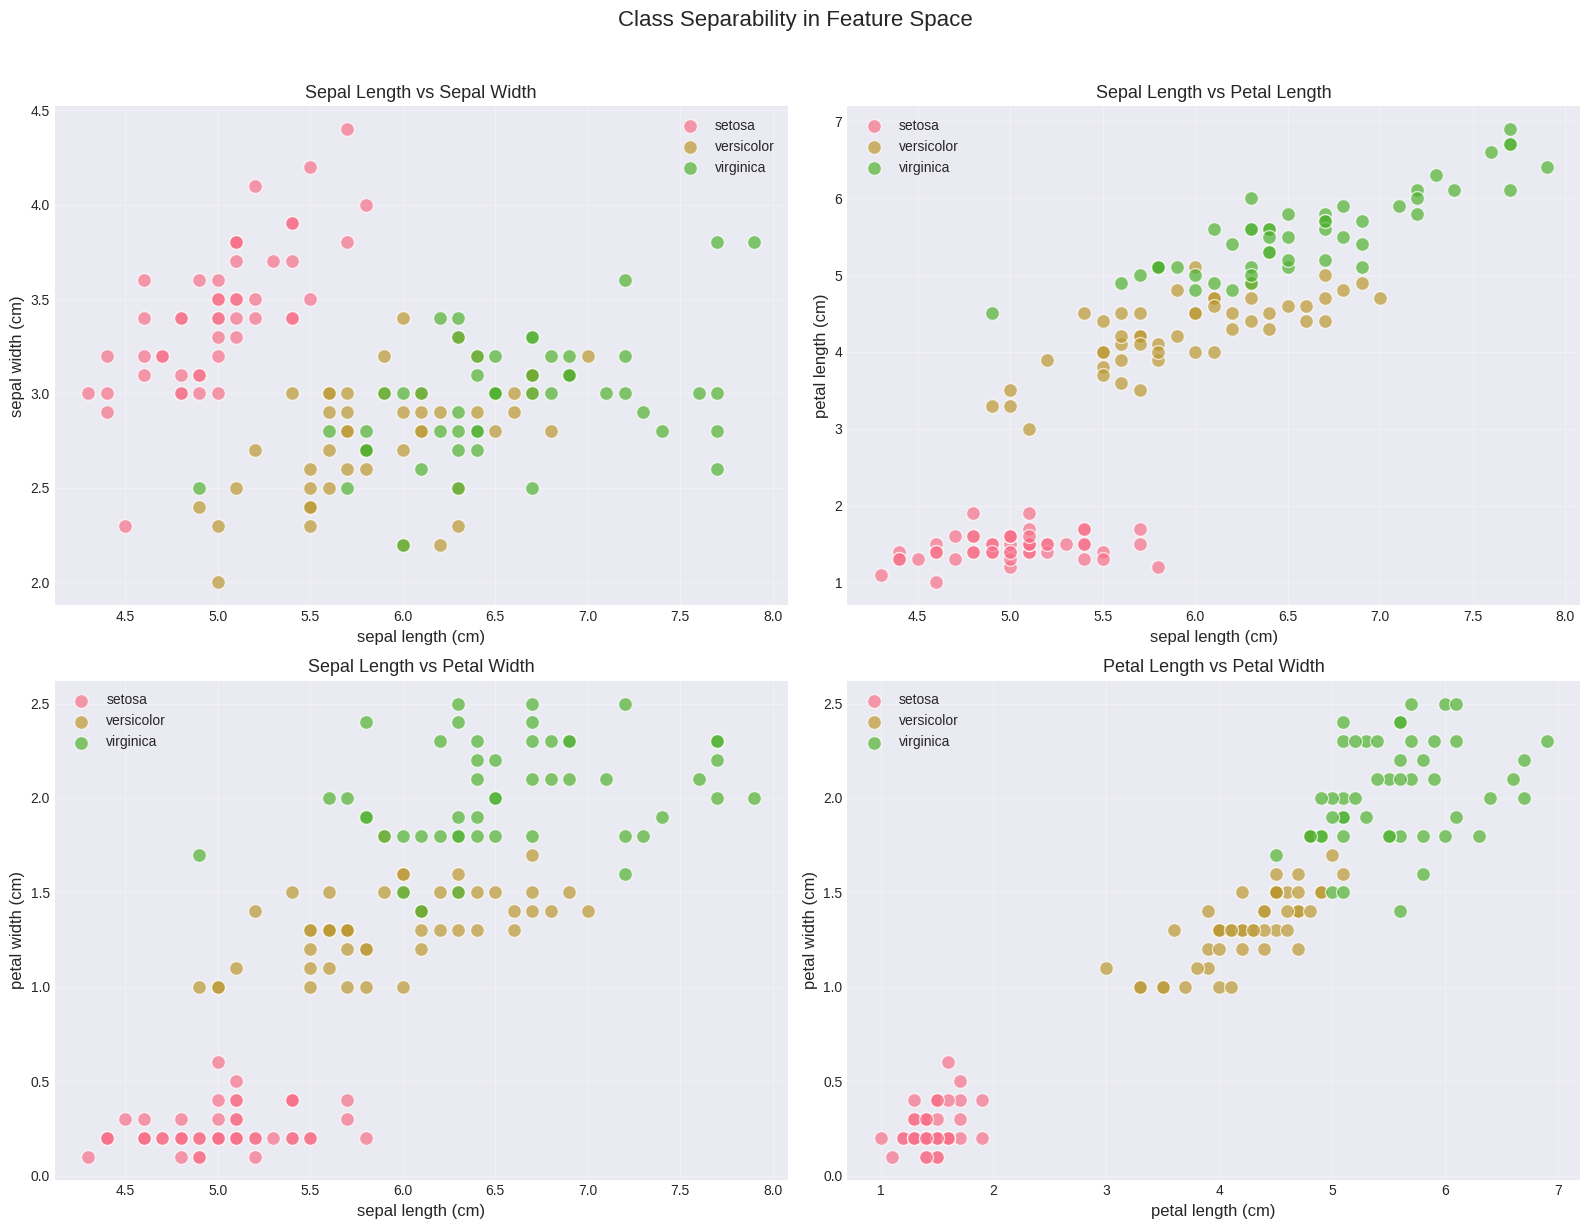

✓ Scatter plots saved as 'plots/scatter_separability.png'


In [12]:
# 3.5 Scatter Plots - 2D Feature Space
print("\n" + "="*70)
print("3.5 CLASS SEPARABILITY - SCATTER PLOTS")
print("="*70)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

# Pair combinations
feature_pairs = [(0, 1), (0, 2), (0, 3), (2, 3)]
titles = ['Sepal Length vs Sepal Width', 'Sepal Length vs Petal Length',
          'Sepal Length vs Petal Width', 'Petal Length vs Petal Width']

for idx, (f1, f2) in enumerate(feature_pairs):
    for species in target_names:
        subset = df[df['species_name'] == species]
        axes[idx].scatter(subset[feature_names[f1]], subset[feature_names[f2]],
                         label=species, alpha=0.7, s=100, edgecolors='white')
    axes[idx].set_xlabel(feature_names[f1], fontsize=12)
    axes[idx].set_ylabel(feature_names[f2], fontsize=12)
    axes[idx].set_title(titles[idx], fontsize=13)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle('Class Separability in Feature Space', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/scatter_separability.png', dpi=300)
plt.show()
print("✓ Scatter plots saved as 'plots/scatter_separability.png'")

In [13]:
# ============================================
# 4. DATA PREPROCESSING
# ============================================

print("="*70)
print("DATA PREPROCESSING")
print("="*70)

# Split features and target
X = df[feature_names].values
y = df['species'].values

# Train-test split (80-20 with stratification)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

# Standardize features for k-NN and Logistic Regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling applied (StandardScaler)")
print(f"Training data mean (scaled): {X_train_scaled.mean(axis=0).round(3)}")
print(f"Training data std (scaled): {X_train_scaled.std(axis=0).round(3)}")
print(f"Scaling parameters saved for inference")

# Save scaler for later use
joblib.dump(scaler, 'models/scaler.pkl')
print("\n✓ Scaler saved as 'models/scaler.pkl'")

DATA PREPROCESSING
Training set: 120 samples (80.0%)
Test set: 30 samples (20.0%)

Feature scaling applied (StandardScaler)
Training data mean (scaled): [-0. -0.  0.  0.]
Training data std (scaled): [1. 1. 1. 1.]
Scaling parameters saved for inference

✓ Scaler saved as 'models/scaler.pkl'


In [14]:
# ============================================
# 5. MODEL TRAINING AND EVALUATION
# ============================================

print("="*70)
print("MODEL TRAINING AND EVALUATION")
print("="*70)

# Initialize models
models = {
    'k-NN': KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression': LogisticRegression(max_iter=200, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42)
}

# Store results
results = {}
predictions = {}
trained_models = {}
cv_scores = {}

print("\nTraining models...\n")

for name, model in models.items():
    print("-"*60)
    print(f"Training {name}...")

    # Select appropriate data
    if name in ['k-NN', 'Logistic Regression']:
        X_train_use = X_train_scaled
        X_test_use = X_test_scaled
        print("  Using scaled data")
    else:
        X_train_use = X_train
        X_test_use = X_test
        print("  Using original data")

    # Train model
    model.fit(X_train_use, y_train)
    trained_models[name] = model

    # Make predictions
    y_pred = model.predict(X_test_use)
    predictions[name] = y_pred

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Cross-validation
    cv_scores = cross_val_score(model, X_train_use, y_train, cv=5)

    # Store results
    results[name] = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'y_pred': y_pred
    }

    # Print results
    print(f"\n  Results:")
    print(f"    Accuracy: {accuracy:.4f}")
    print(f"    Precision (weighted): {precision:.4f}")
    print(f"    Recall (weighted): {recall:.4f}")
    print(f"    F1-Score (weighted): {f1:.4f}")
    print(f"    CV Score: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    print(f"\n  Confusion Matrix:")
    print(cm)
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=target_names))
    print("-"*60)

MODEL TRAINING AND EVALUATION

Training models...

------------------------------------------------------------
Training k-NN...
  Using scaled data

  Results:
    Accuracy: 0.9333
    Precision (weighted): 0.9444
    Recall (weighted): 0.9333
    F1-Score (weighted): 0.9327
    CV Score: 0.9667 (±0.0312)

  Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  2  8]]

  Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30

------------------------------------------------------------
------------------------------------------------------------
Training Logistic Regression...
  Using scaled data

  Results:
    Accuracy: 0.9333
    Precision (weigh

In [15]:
# ============================================
# 6. HYPERPARAMETER TUNING
# ============================================

print("="*70)
print("HYPERPARAMETER TUNING WITH GRID SEARCH")
print("="*70)

# 6.1 k-NN Tuning
print("\n6.1 Tuning k-NN...")
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 13, 15, 17, 19]}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_params, cv=5,
                       scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train_scaled, y_train)
best_knn = knn_grid.best_estimator_
print(f"  Best parameters: {knn_grid.best_params_}")
print(f"  Best CV accuracy: {knn_grid.best_score_:.4f}")

# 6.2 Logistic Regression Tuning
print("\n6.2 Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'penalty': ['l2']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=300, random_state=42),
                       lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train_scaled, y_train)
best_lr = lr_grid.best_estimator_
print(f"  Best parameters: {lr_grid.best_params_}")
print(f"  Best CV accuracy: {lr_grid.best_score_:.4f}")

# 6.3 Decision Tree Tuning
print("\n6.3 Tuning Decision Tree...")
dt_params = {
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10, None],
    'min_samples_split': [2, 5, 10, 15, 20],
    'min_samples_leaf': [1, 2, 4, 6]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt = dt_grid.best_estimator_
print(f"  Best parameters: {dt_grid.best_params_}")
print(f"  Best CV accuracy: {dt_grid.best_score_:.4f}")

# Evaluate tuned models
tuned_models = {
    'k-NN (tuned)': best_knn,
    'Logistic Regression (tuned)': best_lr,
    'Decision Tree (tuned)': best_dt
}

tuned_results = {}
print("\n" + "-"*60)
print("TUNED MODEL EVALUATION ON TEST SET")
print("-"*60)

for name, model in tuned_models.items():
    base_name = name.split()[0]
    if base_name in ['k-NN', 'Logistic']:
        X_test_use = X_test_scaled
    else:
        X_test_use = X_test

    y_pred = model.predict(X_test_use)
    accuracy = accuracy_score(y_test, y_pred)
    tuned_results[name] = {
        'accuracy': accuracy,
        'y_pred': y_pred
    }
    print(f"{name}: Accuracy = {accuracy:.4f}")

HYPERPARAMETER TUNING WITH GRID SEARCH

6.1 Tuning k-NN...
  Best parameters: {'n_neighbors': 5}
  Best CV accuracy: 0.9667

6.2 Tuning Logistic Regression...
  Best parameters: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV accuracy: 0.9667

6.3 Tuning Decision Tree...
  Best parameters: {'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
  Best CV accuracy: 0.9417

------------------------------------------------------------
TUNED MODEL EVALUATION ON TEST SET
------------------------------------------------------------
k-NN (tuned): Accuracy = 0.9333
Logistic Regression (tuned): Accuracy = 1.0000
Decision Tree (tuned): Accuracy = 0.9333


MODEL COMPARISON

Model Performance Comparison:


,Model,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,k-NN,0.9333,0.9444,0.9333,0.9327,0.9667,0.0312
1,Logistic Regression,0.9333,0.9333,0.9333,0.9333,0.9583,0.0264
2,Decision Tree,0.9333,0.9333,0.9333,0.9333,0.9417,0.0204
3,k-NN (tuned),0.9333,NaN,NaN,NaN,NaN,NaN
4,Logistic Regression (tuned),1.0000,NaN,NaN,NaN,NaN,NaN
5,Decision Tree (tuned),0.9333,NaN,NaN,NaN,NaN,NaN


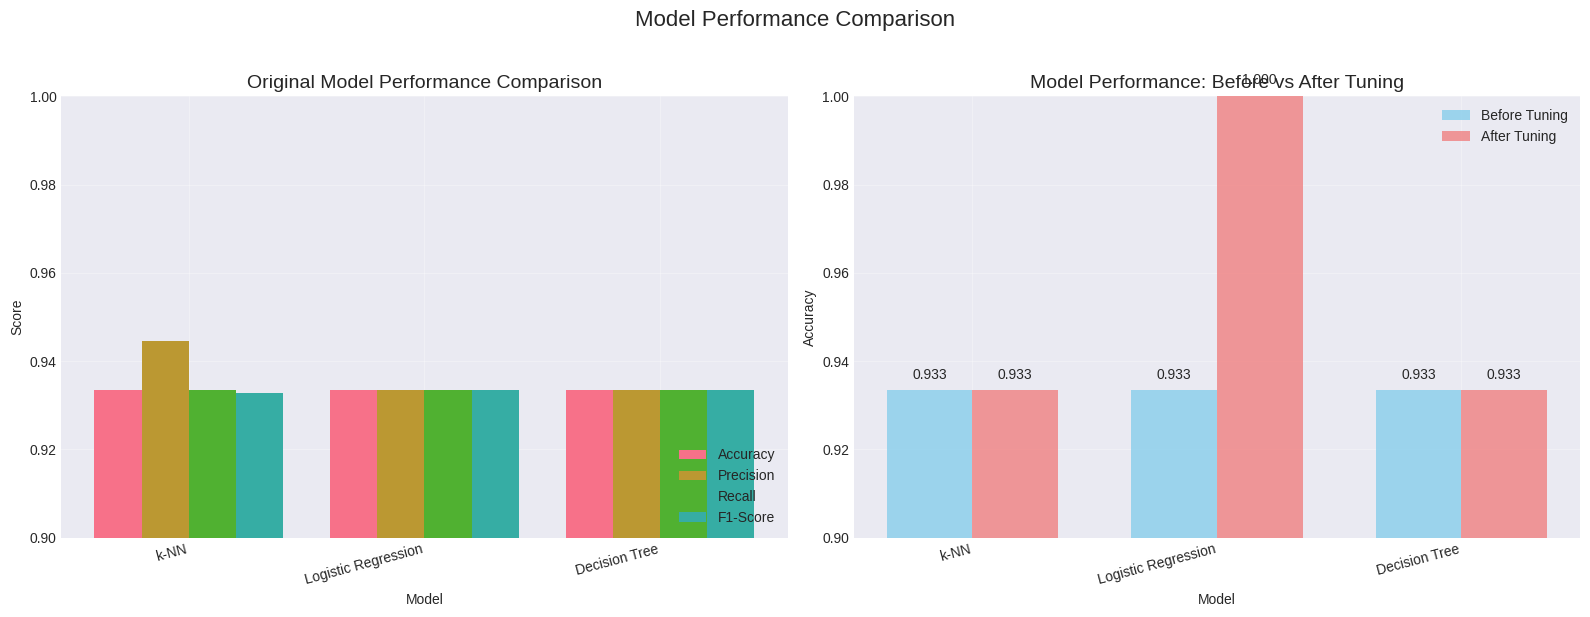

✓ Model comparison saved as 'plots/model_comparison.png'


In [16]:
# ============================================
# 7. MODEL COMPARISON
# ============================================

print("="*70)
print("MODEL COMPARISON")
print("="*70)

# Create comparison DataFrame
comparison_data = []
for name, metrics in results.items():
    comparison_data.append({
        'Model': name,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1-Score': metrics['f1'],
        'CV Mean': metrics['cv_mean'],
        'CV Std': metrics['cv_std']
    })

comparison_df = pd.DataFrame(comparison_data)

# Add tuned models
for name, metrics in tuned_results.items():
    comparison_df = pd.concat([
        comparison_df,
        pd.DataFrame({
            'Model': [name],
            'Accuracy': [metrics['accuracy']],
            'Precision': [None],
            'Recall': [None],
            'F1-Score': [None],
            'CV Mean': [None],
            'CV Std': [None]
        })
    ], ignore_index=True)

print("\nModel Performance Comparison:")
display(comparison_df.round(4))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot for original models
ax1 = axes[0]
original_models = comparison_df.iloc[:3]
x = np.arange(len(original_models))
width = 0.2
multiplier = 0
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

for metric in metrics_plot:
    offset = width * multiplier
    ax1.bar(x + offset, original_models[metric], width, label=metric)
    multiplier += 1

ax1.set_xlabel('Model')
ax1.set_ylabel('Score')
ax1.set_title('Original Model Performance Comparison', fontsize=14)
ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(original_models['Model'], rotation=15, ha='right')
ax1.legend(loc='lower right')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.9, 1.0)

# Tuning comparison
ax2 = axes[1]
model_names = ['k-NN', 'Logistic Regression', 'Decision Tree']
before_acc = [results[name]['accuracy'] for name in model_names]
after_acc = [tuned_results[f'{name} (tuned)']['accuracy'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

bars1 = ax2.bar(x - width/2, before_acc, width, label='Before Tuning',
                alpha=0.8, color='skyblue')
bars2 = ax2.bar(x + width/2, after_acc, width, label='After Tuning',
                alpha=0.8, color='lightcoral')

ax2.set_xlabel('Model')
ax2.set_ylabel('Accuracy')
ax2.set_title('Model Performance: Before vs After Tuning', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=15, ha='right')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0.9, 1.0)

# Add value labels on bars
for i, (before, after) in enumerate(zip(before_acc, after_acc)):
    ax2.text(i - width/2, before + 0.002, f'{before:.3f}',
             ha='center', va='bottom', fontsize=10)
    ax2.text(i + width/2, after + 0.002, f'{after:.3f}',
             ha='center', va='bottom', fontsize=10)

plt.suptitle('Model Performance Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=300)
plt.show()
print("✓ Model comparison saved as 'plots/model_comparison.png'")

CONFUSION MATRICES


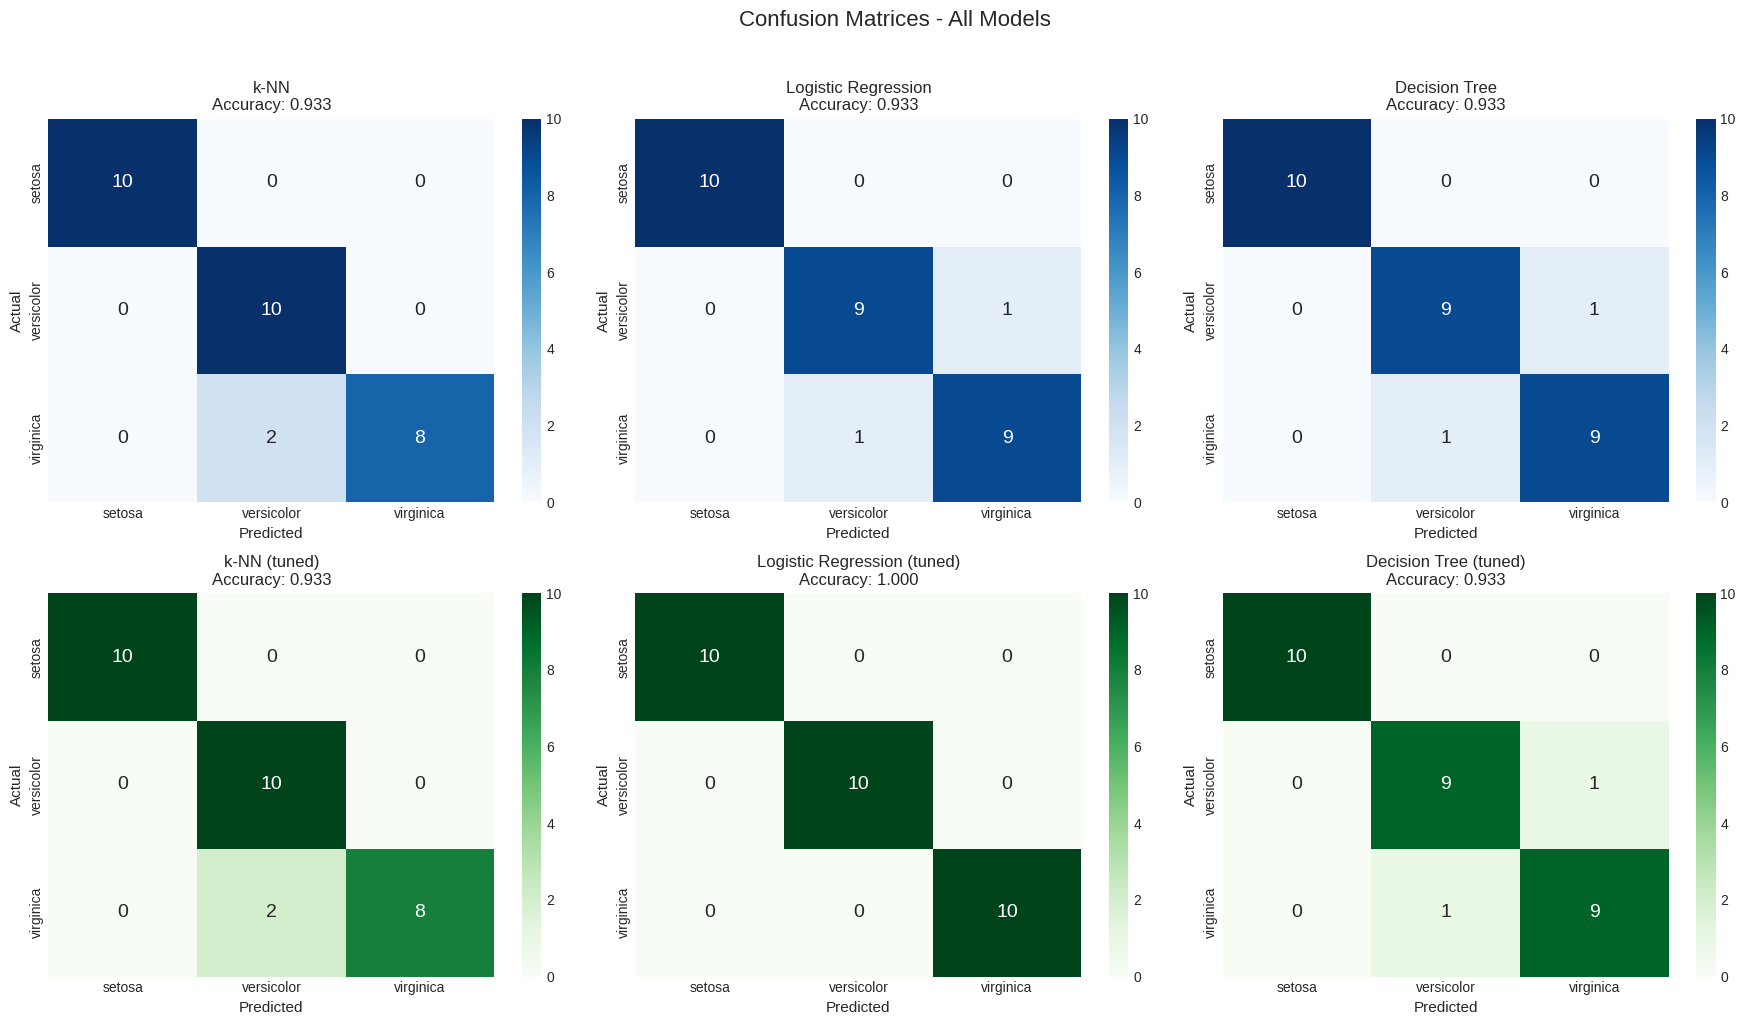

✓ All confusion matrices saved as 'plots/all_confusion_matrices.png'


In [17]:
# ============================================
# 8. CONFUSION MATRICES
# ============================================

print("="*70)
print("CONFUSION MATRICES")
print("="*70)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

# Plot confusion matrices for original models
for idx, name in enumerate(models.keys()):
    cm = confusion_matrix(y_test, predictions[name])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[idx], cbar=True, annot_kws={'size': 14})
    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["accuracy"]:.3f}',
                        fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

# Plot confusion matrices for tuned models
for idx, (name, metrics) in enumerate(tuned_results.items(), start=3):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=target_names, yticklabels=target_names,
                ax=axes[idx], cbar=True, annot_kws={'size': 14})
    axes[idx].set_title(f'{name}\nAccuracy: {metrics["accuracy"]:.3f}',
                        fontsize=12)
    axes[idx].set_xlabel('Predicted', fontsize=11)
    axes[idx].set_ylabel('Actual', fontsize=11)

# Hide any unused subplot (if any)
if len(axes) > 6:
    axes[5].set_visible(False)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('plots/all_confusion_matrices.png', dpi=300)
plt.show()
print("✓ All confusion matrices saved as 'plots/all_confusion_matrices.png'")

DECISION TREE VISUALIZATION


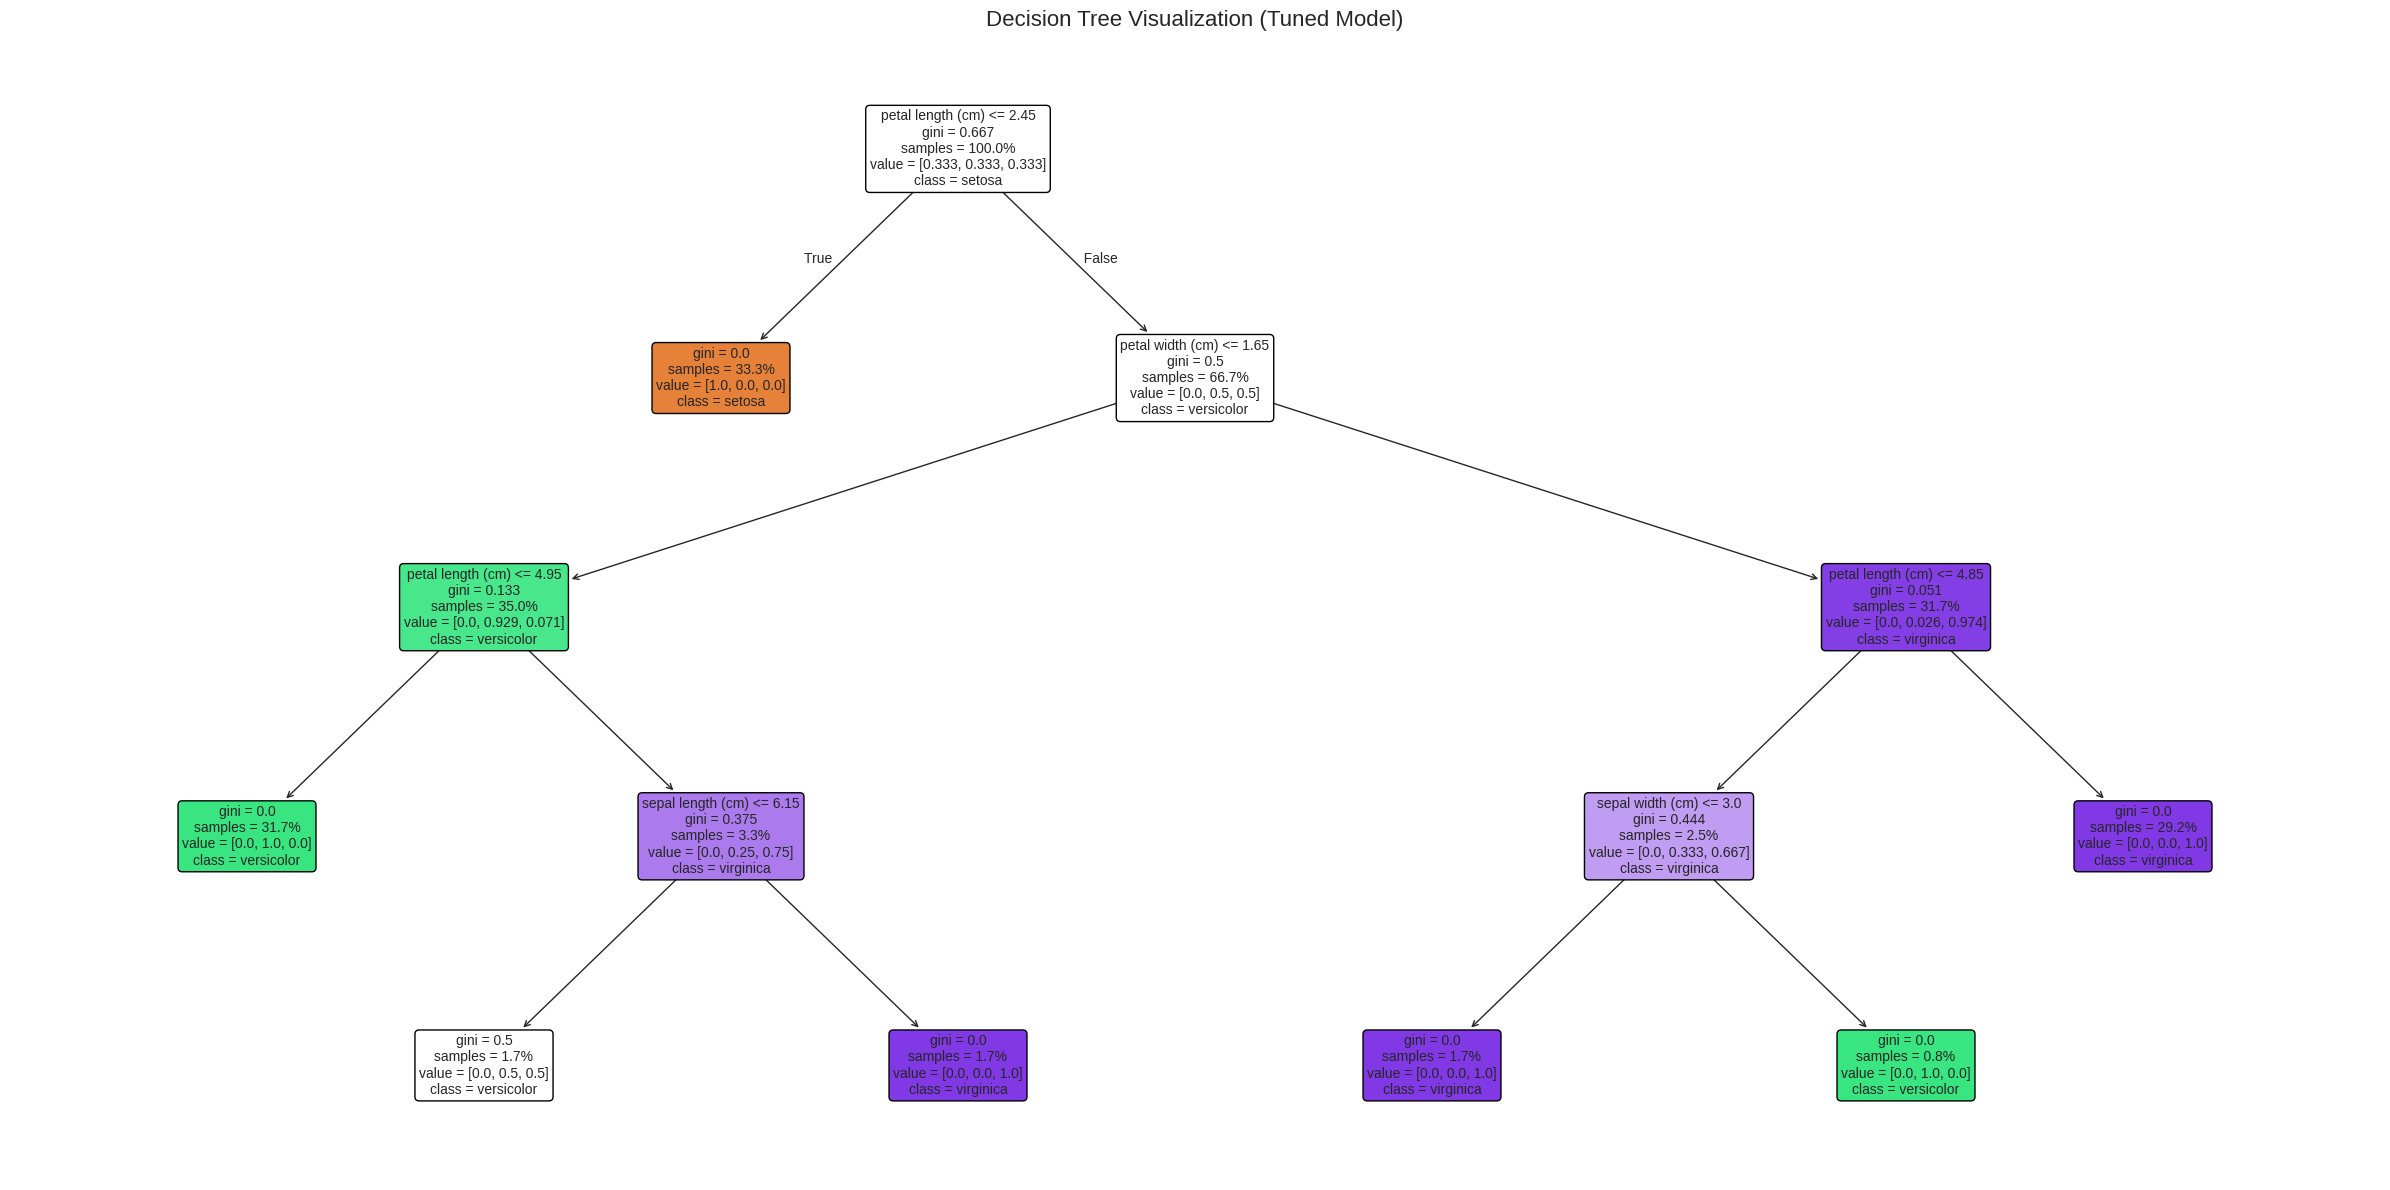

✓ Decision tree saved as 'plots/decision_tree_viz.png'

Decision Tree Feature Importance:


,Feature,Importance
2,petal length (cm),0.565639
3,petal width (cm),0.411154
1,sepal width (cm),0.016878
0,sepal length (cm),0.006329


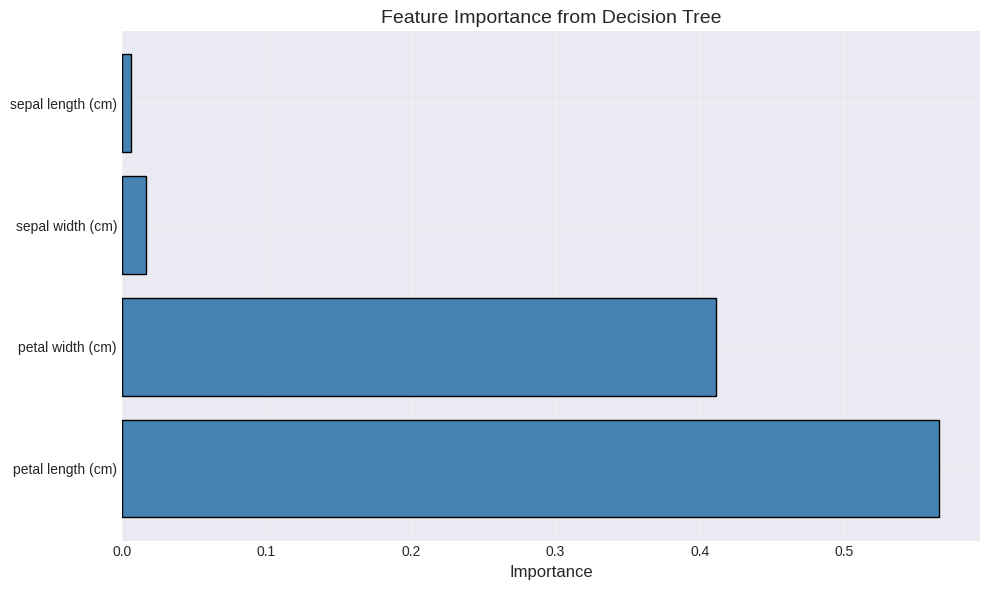

✓ Feature importance saved as 'plots/feature_importance.png'


In [18]:
# ============================================
# 9. DECISION TREE VISUALIZATION
# ============================================

print("="*70)
print("DECISION TREE VISUALIZATION")
print("="*70)

# Get the tuned Decision Tree
dt_model = tuned_models['Decision Tree (tuned)']

# Visualize the tree
plt.figure(figsize=(24, 12))
plot_tree(dt_model, feature_names=feature_names,
          class_names=target_names, filled=True,
          rounded=True, fontsize=10, proportion=True)
plt.title('Decision Tree Visualization (Tuned Model)', fontsize=16)
plt.tight_layout()
plt.savefig('plots/decision_tree_viz.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Decision tree saved as 'plots/decision_tree_viz.png'")

# Feature Importance
print("\nDecision Tree Feature Importance:")
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)
display(importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color='steelblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.title('Feature Importance from Decision Tree', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/feature_importance.png', dpi=300)
plt.show()
print("✓ Feature importance saved as 'plots/feature_importance.png'")

BEST MODEL SELECTION & SAVING
Best Model: Logistic Regression (tuned)
Test Accuracy: 1.0000 (100.00%)

✓ Model saved as 'models/best_iris_model.joblib'
✓ Model saved as 'models/best_iris_model.pkl'
✓ Model also saved in root directory

Best Model Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



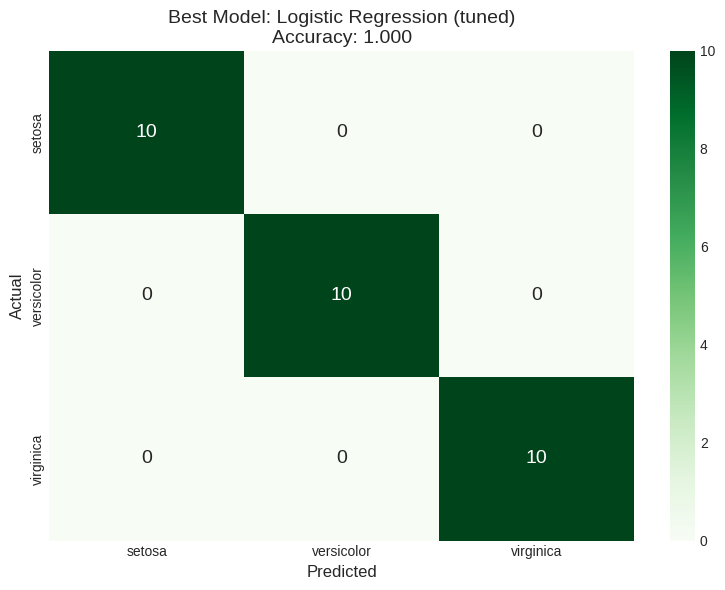

✓ Best model confusion matrix saved as 'plots/best_model_confusion_matrix.png'


In [19]:
# ============================================
# 10. SELECT AND SAVE BEST MODEL
# ============================================

print("="*70)
print("BEST MODEL SELECTION & SAVING")
print("="*70)

# Select best model based on test accuracy
best_model_name = max(tuned_results, key=lambda x: tuned_results[x]['accuracy'])
best_model = tuned_models[best_model_name]
best_accuracy = tuned_results[best_model_name]['accuracy']
best_y_pred = tuned_results[best_model_name]['y_pred']

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")

# Determine if scaler is needed
uses_scaler = 'k-NN' in best_model_name or 'Logistic' in best_model_name

# Prepare model info
model_info = {
    'model': best_model,
    'scaler': scaler if uses_scaler else None,
    'feature_names': feature_names,
    'target_names': target_names,
    'accuracy': best_accuracy,
    'model_name': best_model_name,
    'uses_scaler': uses_scaler,
    'training_date': datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'test_size': len(X_test),
    'n_samples': len(X)
}

# Save with joblib
joblib.dump(model_info, 'models/best_iris_model.joblib')
print("\n✓ Model saved as 'models/best_iris_model.joblib'")

# Also save as pickle
with open('models/best_iris_model.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("✓ Model saved as 'models/best_iris_model.pkl'")

# Save to root directory for easy access (Colab compatibility)
joblib.dump(model_info, 'best_iris_model.joblib')
with open('best_iris_model.pkl', 'wb') as f:
    pickle.dump(model_info, f)
print("✓ Model also saved in root directory")

# Generate classification report for best model
print("\nBest Model Classification Report:")
print(classification_report(y_test, best_y_pred, target_names=target_names))

# Confusion matrix for best model
fig, ax = plt.subplots(figsize=(8, 6))
cm_best = confusion_matrix(y_test, best_y_pred)
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names,
            ax=ax, cbar=True, annot_kws={'size': 14})
ax.set_title(f'Best Model: {best_model_name}\nAccuracy: {best_accuracy:.3f}',
             fontsize=14)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
plt.tight_layout()
plt.savefig('plots/best_model_confusion_matrix.png', dpi=300)
plt.show()
print("✓ Best model confusion matrix saved as 'plots/best_model_confusion_matrix.png'")

In [20]:
# ============================================
# 11. INFERENCE EXAMPLES
# ============================================

print("="*70)
print("INFERENCE EXAMPLES")
print("="*70)

# Load the saved model
model_info = joblib.load('best_iris_model.joblib')
model = model_info['model']
scaler = model_info['scaler']
target_names = model_info['target_names']
uses_scaler = model_info['uses_scaler']

print(f"Loaded model: {model_info['model_name']}")
print(f"Uses scaler: {uses_scaler}\n")

# 11.1 Single Sample Prediction
print("-"*60)
print("11.1 SINGLE SAMPLE PREDICTION")
print("-"*60)

def predict_single(sepal_length, sepal_width, petal_length, petal_width):
    """Predict Iris species for a single sample"""
    sample = np.array([[sepal_length, sepal_width, petal_length, petal_width]])

    if uses_scaler and scaler is not None:
        sample = scaler.transform(sample)

    pred = model.predict(sample)[0]
    probs = model.predict_proba(sample)[0]

    return target_names[pred], {name: prob for name, prob in zip(target_names, probs)}

# Test samples
test_samples = [
    (5.1, 3.5, 1.4, 0.2),   # Iris-setosa
    (6.5, 3.0, 5.2, 2.0),   # Iris-virginica
    (5.5, 2.5, 4.0, 1.3),   # Iris-versicolor
]

for sample in test_samples:
    species, probs = predict_single(*sample)
    print(f"\nSample: Sepal={sample[0]}, SepalW={sample[1]}, Petal={sample[2]}, PetalW={sample[3]}")
    print(f"Predicted: {species}")
    print("Probabilities:")
    for name, prob in probs.items():
        print(f"  {name}: {prob:.4f}")

# 11.2 Batch Prediction
print("\n" + "-"*60)
print("11.2 BATCH PREDICTION")
print("-"*60)

def predict_batch(samples):
    """Predict Iris species for multiple samples"""
    if uses_scaler and scaler is not None:
        samples_scaled = scaler.transform(samples)
    else:
        samples_scaled = samples

    predictions = model.predict(samples_scaled)
    probabilities = model.predict_proba(samples_scaled)

    results = []
    for pred, probs in zip(predictions, probabilities):
        results.append({
            'species': target_names[pred],
            'probabilities': {name: prob for name, prob in zip(target_names, probs)}
        })
    return results

# Batch examples
batch_samples = np.array([
    [4.9, 3.0, 1.4, 0.2],
    [6.7, 3.1, 4.4, 1.4],
    [6.3, 3.3, 6.0, 2.5]
])

batch_results = predict_batch(batch_samples)
for i, (sample, result) in enumerate(zip(batch_samples, batch_results)):
    print(f"\nSample {i+1}: {sample}")
    print(f"Predicted: {result['species']}")
    print(f"Confidence: {max(result['probabilities'].values()):.4f}")

print("\n" + "="*70)
print("✅ INFERENCE EXAMPLES COMPLETED SUCCESSFULLY!")
print("="*70)

INFERENCE EXAMPLES
Loaded model: Logistic Regression (tuned)
Uses scaler: True

------------------------------------------------------------
11.1 SINGLE SAMPLE PREDICTION
------------------------------------------------------------

Sample: Sepal=5.1, SepalW=3.5, Petal=1.4, PetalW=0.2
Predicted: setosa
Probabilities:
  setosa: 0.9975
  versicolor: 0.0025
  virginica: 0.0000

Sample: Sepal=6.5, SepalW=3.0, Petal=5.2, PetalW=2.0
Predicted: virginica
Probabilities:
  setosa: 0.0000
  versicolor: 0.0416
  virginica: 0.9584

Sample: Sepal=5.5, SepalW=2.5, Petal=4.0, PetalW=1.3
Predicted: versicolor
Probabilities:
  setosa: 0.0035
  versicolor: 0.9849
  virginica: 0.0116

------------------------------------------------------------
11.2 BATCH PREDICTION
------------------------------------------------------------

Sample 1: [4.9 3.  1.4 0.2]
Predicted: setosa
Confidence: 0.9882

Sample 2: [6.7 3.1 4.4 1.4]
Predicted: versicolor
Confidence: 0.9894

Sample 3: [6.3 3.3 6.  2.5]
Predicted: virgi